# XGBoost Phase 3: Weather Covariates

This notebook implements the third phase of the XGBoost benchmark. We build upon the **Direct Multi-Step (Rich Lags + Calendar)** strategy and incorporate a comprehensive set of weather covariates to capture demand spikes driven by environmental conditions.

## Objective
Evaluate the performance impact of adding explicitly encoded weather features (perfect foresight proxy):
- Temperature & Apparent Temperature
- Relative Humidity & Dew Point
- Wind Speed
- Cloud Cover & Precipitation
- Shortwave Radiation

We compare this "Weather Aware" model against Phase 2 (Calendar) and Chronos-2 benchmarks.

In [6]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Constants
HORIZON = 24

## 1. Data Preparation

We load energy load data and merge it with the comprehensive weather dataset.

In [7]:
def load_ercot_data():
    files = sorted(glob.glob('../../data/ercot/raw/ercot_20*.xlsx'))
    dfs = []
    for f in files:
        df = pd.read_excel(f)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    
    def parse_ercot_datetime(s):
        s = str(s).replace(' DST', '')
        if s.endswith('24:00'):
            return pd.to_datetime(s.replace('24:00', '00:00')) + pd.Timedelta(days=1) - pd.Timedelta(hours=1)
        else:
            return pd.to_datetime(s) - pd.Timedelta(hours=1)

    df['timestamp'] = df['Hour Ending'].apply(parse_ercot_datetime)
    df = df[['timestamp', 'NCENT']].copy()
    df.rename(columns={'NCENT': 'target'}, inplace=True)
    df = df.sort_values('timestamp').set_index('timestamp')
    df = df.resample('h').mean()
    df['target'] = df['target'].interpolate()
    return df

def load_weather_data():
    files = sorted(glob.glob('../../data/ercot/raw/open-meteo-dallas-*.csv'))
    dfs = []
    for f in files:
        # Skip the metadata rows in Open-Meteo CSVs
        df_w = pd.read_csv(f, skiprows=3)
        dfs.append(df_w)
    df_w = pd.concat(dfs, ignore_index=True)
    
    df_w['timestamp'] = pd.to_datetime(df_w['time'])
    df_w = df_w.rename(columns={
        'temperature_2m (°C)': 'temp',
        'relative_humidity_2m (%)': 'humidity',
        'dew_point_2m (°C)': 'dew_point',
        'apparent_temperature (°C)': 'apparent_temp',
        'wind_speed_10m (km/h)': 'wind_speed',
        'cloud_cover (%)': 'cloud_cover',
        'precipitation (mm)': 'precip',
        'shortwave_radiation (W/m²)': 'radiation'
    })
    
    cols = ['timestamp', 'temp', 'humidity', 'dew_point', 'apparent_temp', 'wind_speed', 'cloud_cover', 'precip', 'radiation']
    df_w = df_w[cols].set_index('timestamp')
    df_w = df_w.resample('h').mean().interpolate()
    return df_w

df_load = load_ercot_data()
df_weather = load_weather_data()

# Merge datasets
df = df_load.join(df_weather, how='inner')
print(f"Merged data from {df.index.min()} to {df.index.max()}")

Merged data from 2023-01-01 00:00:00 to 2026-03-31 23:00:00


## 2. Feature Engineering

In [8]:
tx_holidays = holidays.US(state='TX')

def get_calendar_features(dt_index):
    features = pd.DataFrame(index=dt_index)
    features['hour'] = dt_index.hour
    features['dayofweek'] = dt_index.dayofweek
    features['is_weekend'] = (dt_index.dayofweek >= 5).astype(int)
    features['month'] = dt_index.month
    features['is_holiday'] = pd.Series(dt_index).apply(lambda x: x in tx_holidays).values.astype(int)
    return features

## 3. Training Strategy B (Direct + Weather)

For each model $h$, we use:
- Lags from origin $T$
- Calendar features for target $T+h$
- Weather features for target $T+h$

In [9]:
train_end = '2025-07-31 23:00:00'
train_df = df[:train_end].copy()

print("Training Strategy B (Direct + Weather)...")
models_direct = {}

lag_cols = ['feat_origin', 'feat_origin_m1', 'feat_origin_m2', 
            'feat_24h_aligned', 'feat_48h_aligned', 'feat_168h_aligned']
cal_cols = ['target_hour', 'target_dayofweek', 'target_is_weekend', 'target_month', 'target_is_holiday']
weather_cols = ['target_temp', 'target_humidity', 'target_dew_point', 'target_apparent_temp', 
                'target_wind_speed', 'target_cloud_cover', 'target_precip', 'target_radiation']

feature_cols = lag_cols + cal_cols + weather_cols

for h in range(1, HORIZON + 1):
    df_h = df.copy()
    df_h['target_h'] = df_h['target'].shift(-h)
    
    # Lags (Origin T)
    df_h['feat_origin'] = df_h['target']
    df_h['feat_origin_m1'] = df_h['target'].shift(1)
    df_h['feat_origin_m2'] = df_h['target'].shift(2)
    df_h['feat_24h_aligned'] = df_h['target'].shift(24 - h)
    df_h['feat_48h_aligned'] = df_h['target'].shift(48 - h)
    df_h['feat_168h_aligned'] = df_h['target'].shift(168 - h)
    
    # Calendar (Target T+h)
    target_times = df_h.index + pd.Timedelta(hours=h)
    cal_feats = get_calendar_features(target_times)
    df_h['target_hour'] = cal_feats['hour'].values
    df_h['target_dayofweek'] = cal_feats['dayofweek'].values
    df_h['target_is_weekend'] = cal_feats['is_weekend'].values
    df_h['target_month'] = cal_feats['month'].values
    df_h['target_is_holiday'] = cal_feats['is_holiday'].values
    
    # Weather (Target T+h)
    df_h['target_temp'] = df_h['temp'].shift(-h)
    df_h['target_humidity'] = df_h['humidity'].shift(-h)
    df_h['target_dew_point'] = df_h['dew_point'].shift(-h)
    df_h['target_apparent_temp'] = df_h['apparent_temp'].shift(-h)
    df_h['target_wind_speed'] = df_h['wind_speed'].shift(-h)
    df_h['target_cloud_cover'] = df_h['cloud_cover'].shift(-h)
    df_h['target_precip'] = df_h['precip'].shift(-h)
    df_h['target_radiation'] = df_h['radiation'].shift(-h)
    
    df_h = df_h.dropna()
    train_h = df_h[:train_end]
    
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
    m.fit(train_h[feature_cols].astype(float), train_h['target_h'])
    models_direct[h] = m

Training Strategy B (Direct + Weather)...


## 4. Evaluation

In [10]:
def calculate_metrics(y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    mae_naive = mean_absolute_error(y_train[168:], y_train[:-168])
    mase = mae / mae_naive
    return {'MAE': mae, 'RMSE': rmse, 'sMAPE': smape, 'MASE': mase}

def evaluate_weather_direct(test_df):
    all_preds = []
    all_actuals = []
    origins = test_df[test_df.index.hour == 0].index
    for origin in origins:
        if origin + pd.Timedelta(hours=24) > test_df.index[-1]:
            continue
        actual = test_df.loc[origin + pd.Timedelta(hours=1) : origin + pd.Timedelta(hours=24), 'target'].values
        
        preds = []
        for h in range(1, 25):
            target_time = origin + pd.Timedelta(hours=h)
            cal = get_calendar_features(pd.DatetimeIndex([target_time]))
            w = df.loc[target_time]
            
            feats = pd.DataFrame([{
                'feat_origin': df.loc[origin, 'target'],
                'feat_origin_m1': df.loc[origin - pd.Timedelta(hours=1), 'target'],
                'feat_origin_m2': df.loc[origin - pd.Timedelta(hours=2), 'target'],
                'feat_24h_aligned': df.loc[origin - pd.Timedelta(hours=24-h), 'target'],
                'feat_48h_aligned': df.loc[origin - pd.Timedelta(hours=48-h), 'target'],
                'feat_168h_aligned': df.loc[origin - pd.Timedelta(hours=168-h), 'target'],
                'target_hour': cal['hour'].values[0],
                'target_dayofweek': cal['dayofweek'].values[0],
                'target_is_weekend': cal['is_weekend'].values[0],
                'target_month': cal['month'].values[0],
                'target_is_holiday': cal['is_holiday'].values[0],
                'target_temp': w['temp'],
                'target_humidity': w['humidity'],
                'target_dew_point': w['dew_point'],
                'target_apparent_temp': w['apparent_temp'],
                'target_wind_speed': w['wind_speed'],
                'target_cloud_cover': w['cloud_cover'],
                'target_precip': w['precip'],
                'target_radiation': w['radiation']
            }])
            preds.append(models_direct[h].predict(feats[feature_cols].astype(float))[0])
        all_preds.append(preds)
        all_actuals.append(actual)
    return np.array(all_actuals), np.array(all_preds)

aug_df = df['2025-08-01 00:00:00':'2025-08-31 23:00:00']
mar_df = df['2026-03-01 00:00:00':'2026-03-31 23:00:00']

for window_name, test_df in [("August 2025", aug_df), ("March 2026", mar_df)]:
    act, p_dir = evaluate_weather_direct(test_df)
    print(f"\nResults for {window_name} (Weather Aware):")
    print(calculate_metrics(act.flatten(), p_dir.flatten(), train_df['target']))


Results for August 2025 (Weather Aware):
{'MAE': 637.2385623110243, 'RMSE': np.float64(849.2712466014917), 'sMAPE': np.float64(3.279407524330882), 'MASE': 0.332292953042981}

Results for March 2026 (Weather Aware):
{'MAE': 542.0695807841147, 'RMSE': np.float64(695.3192915329549), 'sMAPE': np.float64(4.051495397874625), 'MASE': 0.2826663551249557}


## 5. Visualization

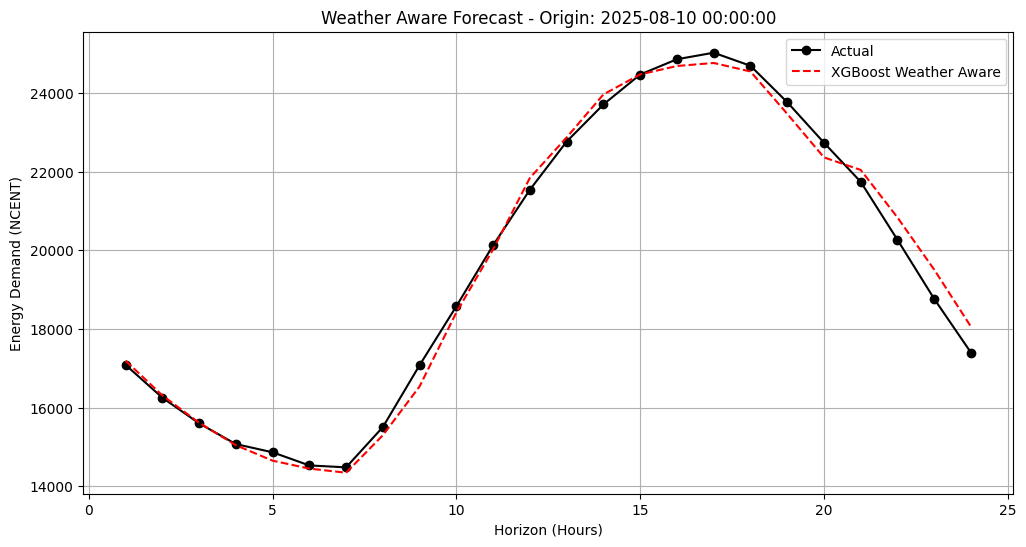

In [11]:
sample_origin = pd.to_datetime('2025-08-10 00:00:00')
act_sample = aug_df.loc[sample_origin + pd.Timedelta(hours=1) : sample_origin + pd.Timedelta(hours=24), 'target'].values

wea_preds = []
for h in range(1, 25):
    target_time = sample_origin + pd.Timedelta(hours=h)
    cal = get_calendar_features(pd.DatetimeIndex([target_time]))
    w = df.loc[target_time]
    feats = pd.DataFrame([{
        'feat_origin': df.loc[sample_origin, 'target'],
        'feat_origin_m1': df.loc[sample_origin - pd.Timedelta(hours=1), 'target'],
        'feat_origin_m2': df.loc[sample_origin - pd.Timedelta(hours=2), 'target'],
        'feat_24h_aligned': df.loc[sample_origin - pd.Timedelta(hours=24-h), 'target'],
        'feat_48h_aligned': df.loc[sample_origin - pd.Timedelta(hours=48-h), 'target'],
        'feat_168h_aligned': df.loc[sample_origin - pd.Timedelta(hours=168-h), 'target'],
        'target_hour': cal['hour'].values[0],
        'target_dayofweek': cal['dayofweek'].values[0],
        'target_is_weekend': cal['is_weekend'].values[0],
        'target_month': cal['month'].values[0],
        'target_is_holiday': cal['is_holiday'].values[0],
        'target_temp': w['temp'],
        'target_humidity': w['humidity'],
        'target_dew_point': w['dew_point'],
        'target_apparent_temp': w['apparent_temp'],
        'target_wind_speed': w['wind_speed'],
        'target_cloud_cover': w['cloud_cover'],
        'target_precip': w['precip'],
        'target_radiation': w['radiation']
    }])
    wea_preds.append(models_direct[h].predict(feats[feature_cols].astype(float))[0])

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), act_sample, label='Actual', marker='o', color='black')
plt.plot(range(1, 25), wea_preds, label='XGBoost Weather Aware', linestyle='--', color='red')
plt.title(f"Weather Aware Forecast - Origin: {sample_origin}")
plt.xlabel("Horizon (Hours)")
plt.ylabel("Energy Demand (NCENT)")
plt.legend()
plt.grid(True)
plt.show()